In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/turbofan-dataset/train_FD001.txt


In [2]:
index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = [f's_{i}' for i in range(1, 22)] # Creates s_1, s_2, ... s_21
col_names = index_names + setting_names + sensor_names


path = '/kaggle/input/turbofan-dataset/train_FD001.txt' 

df = pd.read_csv(path, sep='\s+', header=None, names=col_names)

In [3]:
print(df.shape)
print('_______________________________')
df.head()

(20631, 26)
_______________________________


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


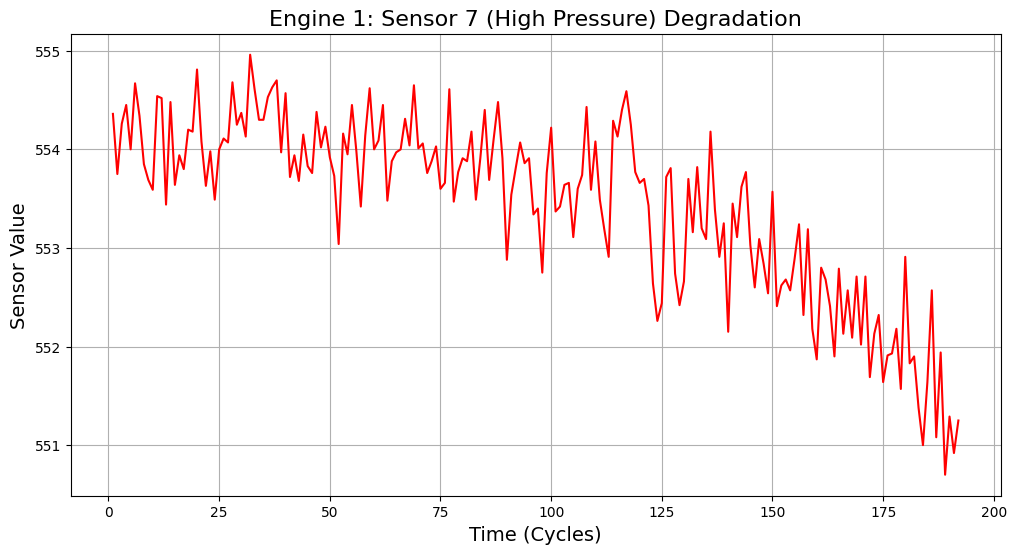

In [4]:
import matplotlib.pyplot as plt
# Let's extract only the data for Engine #1
engine_1 = df[df['unit_nr'] == 1]

# Plot Sensor 7 over time
plt.figure(figsize=(12, 6))
plt.plot(engine_1['time_cycles'], engine_1['s_7'], color='red')

plt.title("Engine 1: Sensor 7 (High Pressure) Degradation", fontsize=16)
plt.xlabel("Time (Cycles)", fontsize=14)
plt.ylabel("Sensor Value", fontsize=14)
plt.grid(True)
plt.show()

In [5]:
features = df.columns.difference(['unit_nr', 'time_cycles', 'RUL'])

target_col = 'RUL'


from sklearn.preprocessing import MinMaxScaler

scaler= MinMaxScaler(feature_range=(0,1))

scaled_df = df.copy()
scaled_df[features] = scaler.fit_transform(df[features])

print("Data Scaled successfully!")
print("First 5 rows of Sensor 7 (Before vs After):")
print("Original:", df['s_7'].head(1).values)
print("Scaled:  ", scaled_df['s_7'].head(1).values)

Data Scaled successfully!
First 5 rows of Sensor 7 (Before vs After):
Original: [554.36]
Scaled:   [0.72624799]


   unit_nr  time_cycles  RUL
0        1            1  191
1        1            2  190
2        1            3  189
3        1            4  188
4        1            5  187


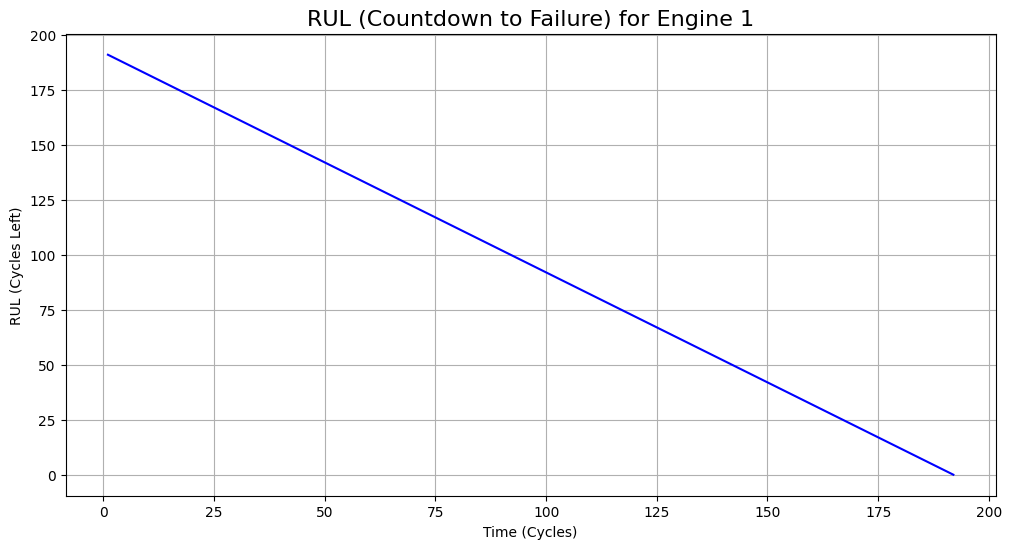

In [6]:
# --- CALCULATE RUL (Remaining Useful Life) ---



max_cycles_df = df.groupby('unit_nr')['time_cycles'].max().reset_index()
max_cycles_df.columns = ['unit_nr', 'max_life']


df = df.merge(max_cycles_df, on='unit_nr', how='left')

df['RUL'] = df['max_life'] - df['time_cycles']


df = df.drop(columns=['max_life'])

print(df[['unit_nr', 'time_cycles', 'RUL']].head())

# ---  RUL FOR ENGINE 1 ---
plt.figure(figsize=(12, 6))
# We filter for Engine 1 again
plt.plot(df[df['unit_nr']==1]['time_cycles'], df[df['unit_nr']==1]['RUL'], color='blue')
plt.title("RUL (Countdown to Failure) for Engine 1", fontsize=16)
plt.xlabel("Time (Cycles)")
plt.ylabel("RUL (Cycles Left)")
plt.grid(True)
plt.show()

In [8]:
from sklearn.preprocessing import MinMaxScaler


features = df.columns.difference(['unit_nr', 'time_cycles', 'RUL'])


target_col = 'RUL'

# 3. Scale the Features
scaler = MinMaxScaler(feature_range=(0, 1))

# We create a new dataframe just for the scaled data so we don't mess up the original
scaled_df = df.copy()
scaled_df[features] = scaler.fit_transform(df[features])

print("Data Scaled successfully!")
print("First 5 rows of Sensor 7 (Before vs After):")
print("Original:", df['s_7'].head(1).values)
print("Scaled:  ", scaled_df['s_7'].head(1).values)

Data Scaled successfully!
First 5 rows of Sensor 7 (Before vs After):
Original: [554.36]
Scaled:   [0.72624799]


In [9]:
import numpy as np

# 1. SETUP
sequence_length = 30  # We want 30-cycle windows
features = [col for col in scaled_df.columns if 's_' in col or 'setting' in col] # All sensors + settings
target_col = 'RUL'

# Create empty lists to hold our "clips"
X_list = []
y_list = []

# 2. LOOP THROUGH EACH ENGINE
# We have engines 1 to 100. We must treat them separately.
# (You can't start a window on Engine 1 and finish it on Engine 2!)
for engine_id in scaled_df['unit_nr'].unique():
    
    # Get all data for THIS specific engine
    engine_data = scaled_df[scaled_df['unit_nr'] == engine_id]
    
    # Convert to a simple matrix of numbers (no more pandas dataframe for now)
    engine_matrix = engine_data[features].values
    engine_rul = engine_data[target_col].values
    
    # 3. CREATE WINDOWS (SLICING)
    # If an engine ran for 192 cycles, we can create (192 - 30) windows.
    num_samples = len(engine_data) - sequence_length
    
    for i in range(num_samples):
        # Create a window: Start at 'i', stop at 'i + 30'
        # Example: Row 0 to 30
        window = engine_matrix[i : i + sequence_length]
        
        # Get the Target: The RUL at the END of this window
        # Example: The RUL at Row 30
        label = engine_rul[i + sequence_length]
        
        # Store them
        X_list.append(window)
        y_list.append(label)

# 4. CONVERT TO NUMPY ARRAYS
# The AI needs "Numpy Arrays", not Python Lists.
X_train = np.array(X_list)
y_train = np.array(y_list)

print("✅ Done!")
print(f"X_train Shape: {X_train.shape}")
print(f"y_train Shape: {y_train.shape}")

✅ Done!
X_train Shape: (17631, 30, 24)
y_train Shape: (17631,)


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# --- 1. DEFINE THE MODEL ARCHITECTURE ---
model = Sequential()

# Layer 1: LSTM (The Brain)
# units=64: The brain has 64 "memory cells" to find patterns.
# input_shape=(30, 24): It expects 30 time steps and 24 sensors.
# return_sequences=False: We only need the output at the very end (after reading all 30 steps).
model.add(LSTM(units=64, input_shape=(30, 24), return_sequences=False))

# Layer 2: Dropout (The Filter)
# Randomly ignores 20% of neurons during training. 
# This stops the model from "memorizing" the answer (overfitting).
model.add(Dropout(0.2))

# Layer 3: Dense (The Output)
# units=1: We want exactly ONE number as output (The RUL).
model.add(Dense(units=1))

# --- 2. COMPILE THE MODEL ---
# Optimizer='adam': A smart algorithm that adjusts the model to learn faster.
# Loss='mean_squared_error': We measure how "far off" our guess is from the real RUL.
model.compile(optimizer='adam', loss='mean_squared_error')

# Show us the design
model.summary()

# --- 3. TRAIN THE MODEL (This takes about 1-2 minutes) ---
# epochs=20: Go through the entire dataset 20 times.
# batch_size=32: Study 32 windows at a time.
# validation_split=0.2: Keep 20% of data secret to test itself (like a mock exam).
history = model.fit(X_train, y_train, 
                    epochs=20, 
                    batch_size=32, 
                    validation_split=0.2,
                    verbose=1)

2026-01-13 13:41:38.292915: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768311698.551640     142 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768311698.621975     142 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,849 (89.25 KB)

 Trainable params: 22,849 (89.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 9570.8955 - val_loss: 9994.4121
Epoch 2/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 5787.9839 - val_loss: 7514.1431
Epoch 3/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 4220.9888 - val_loss: 6276.4463
Epoch 4/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 3619.1768 - val_loss: 5715.4365
Epoch 5/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 3329.9866 - val_loss: 4394.4492
Epoch 6/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 2090.4292 - val_loss: 3358.5576
Epoch 7/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 1576.0629 - val_loss: 2666.7427
Epoch 8/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 1279.4272 - val_loss: 2383.4180
Epoch 9/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 1105.2446 - val_loss: 2421.0603
Epoch 10/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 1066.5135 - val_loss: 1922.1707
Epoch 11/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 1007.29

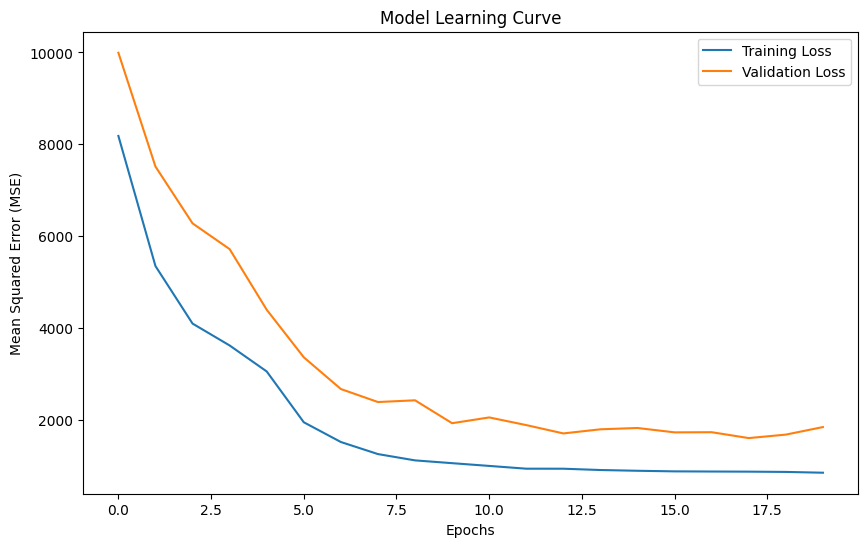

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


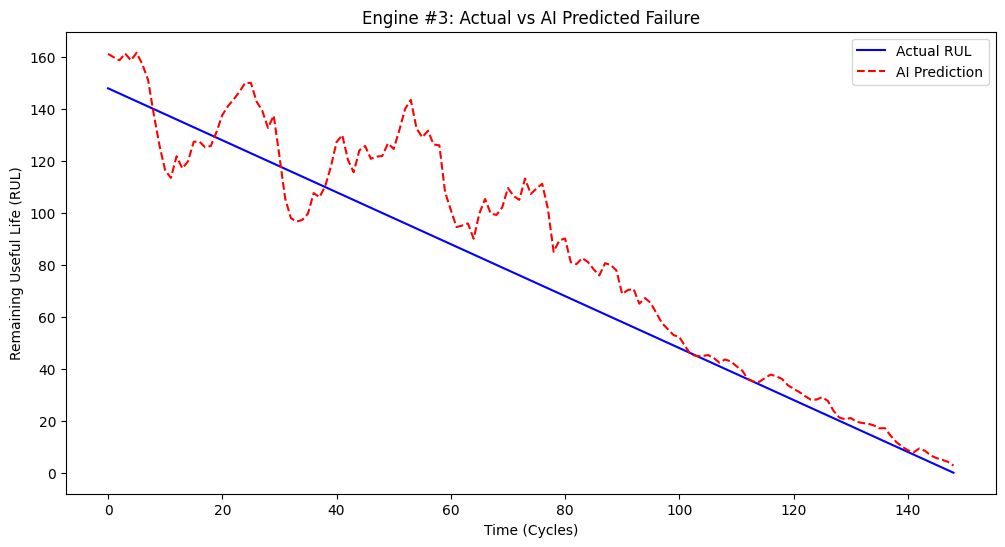

In [13]:
import matplotlib.pyplot as plt

# --- 1. PLOT THE LEARNING CURVE ---
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.show()

# --- 2. THE REAL TEST: PREDICT ON ONE ENGINE ---
# Let's pick Engine #1 from our training data to see how well it learned.
# (Note: X_train is scrambled, so we need to grab the data for Engine 1 again manually)

def get_engine_data(engine_id):
    # Get raw data for one engine
    engine_data = scaled_df[scaled_df['unit_nr'] == engine_id]
    features_data = engine_data[features].values
    
    # Create windows just for this engine
    X_engine = []
    y_true = []
    
    num_samples = len(engine_data) - 30
    
    for i in range(num_samples):
        window = features_data[i : i + 30]
        X_engine.append(window)
        y_true.append(engine_data.iloc[i + 30]['RUL'])
        
    return np.array(X_engine), np.array(y_true)

# Get Engine 3 data (It's a good example)
X_test_engine, y_true_engine = get_engine_data(engine_id=3)

# Ask the AI to predict
y_pred_engine = model.predict(X_test_engine)

# --- 3. PLOT ACTUAL vs PREDICTED ---
plt.figure(figsize=(12, 6))
plt.plot(y_true_engine, label='Actual RUL', color='blue')
plt.plot(y_pred_engine, label='AI Prediction', color='red', linestyle='--')
plt.title('Engine #3: Actual vs AI Predicted Failure')
plt.xlabel('Time (Cycles)')
plt.ylabel('Remaining Useful Life (RUL)')
plt.legend()
plt.show()

Testing on 100 engines...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
---------------------------------------------
 FINAL RMSE SCORE: 19.00
---------------------------------------------


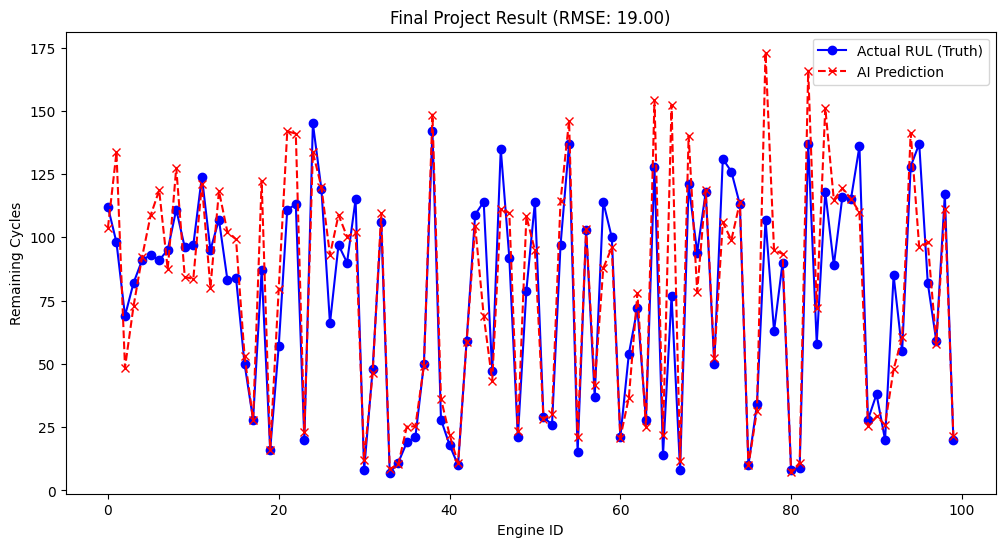

In [17]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error


test_path = '/kaggle/input/turbofan-test-dataset/test_FD001.txt'
rul_path = '/kaggle/input/turbofan-rul/RUL_FD001.txt'


cols = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]
features = ['setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]


test_df = pd.read_csv(test_path, sep='\s+', header=None, names=cols)


try:
    test_df[scaler.feature_names_in_] = scaler.transform(test_df[scaler.feature_names_in_])
except:
    
    test_df[features] = scaler.transform(test_df[features])

# ---  CREATE TEST WINDOWS (Last 30 Cycles) ---
X_test = []
# We iterate through unique engine IDs in the test set
for engine_id in test_df['unit_nr'].unique():
    current_engine = test_df[test_df['unit_nr'] == engine_id]
    
    # We only care about the LAST 30 cycles to predict the end
    if len(current_engine) >= 30:
        current_window = current_engine[features].values[-30:]
        X_test.append(current_window)

X_test = np.array(X_test)

# --- 4. LOAD THE ANSWER KEY (RUL) ---
y_true = pd.read_csv(rul_path, sep='\s+', header=None, names=['RUL'])
y_true = y_true.values

# --- 5. PREDICT & SCORE ---
print(f"Testing on {X_test.shape[0]} engines...")
y_pred = model.predict(X_test)

# Calculate RMSE
rmse = math.sqrt(mean_squared_error(y_true, y_pred))

print(f"---------------------------------------------")
print(f" FINAL RMSE SCORE: {rmse:.2f}")
print(f"---------------------------------------------")



# --- 6. VISUALIZE ---
plt.figure(figsize=(12, 6))
plt.plot(y_true, label='Actual RUL (Truth)', color='blue', marker='o')
plt.plot(y_pred, label='AI Prediction', color='red', marker='x', linestyle='--')
plt.title(f'Final Project Result (RMSE: {rmse:.2f})')
plt.xlabel('Engine ID')
plt.ylabel('Remaining Cycles')
plt.legend()
plt.show()

In [18]:
import joblib 

model.save('rul_model.keras')
joblib.dump(scaler, 'scaler.pkl')
print("1. rul_model.keras")
print("2. scaler.pkl")

1. rul_model.keras
2. scaler.pkl
